# Discovery Yield: Diminishing Returns of Search-Based URL Discovery

**Research question.** RescueAnt's `orchestrator.run()` only reaches for search-engine
discovery once the fetch queue (starting URLs, plus links found while crawling) has run
completely dry, and even then only consumes a small, configurable batch of queries
(`discovery_batch_size`) at a time rather than exhausting the whole query list at once
(see `model.orchestrator.run()`'s docstring). This notebook asks: was that design choice
justified? Concretely, how much does each additional batch of search queries actually
contribute in *new*, previously-undiscovered URLs, as more and more queries are spent?

**Data.** Produced by `experiments/collect_discovery_yield.py`, which runs the project's
real, configured search provider (self-hosted SearXNG, see the README's "Search engines"
section) against the real `search_queries.csv` query-template file, in fixed-size batches
of 5 queries (matching the project's default `discovery_batch_size`), recording the
cumulative and per-batch unique-URL yield. No LLM is involved in this experiment - only
the `SearchProvider`/`discovery_service` layer.

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, integer_axis
import matplotlib.pyplot as plt
import pandas as pd

set_style()
df = load_csv("discovery_yield.csv")
df

,batch,queries_used_cumulative,batch_seconds,batch_unique_urls,batch_new_urls,cumulative_unique_urls
0,0,5,7.624,50,50,50
1,1,10,7.918,50,46,96
2,2,15,5.667,50,44,140
3,3,20,6.048,50,40,180
4,4,25,5.598,49,28,208
5,5,30,5.630,50,23,231
6,6,35,5.610,48,21,252
7,7,40,5.657,46,13,265
8,8,45,5.541,50,41,306
9,9,50,5.719,50,33,339


## Cumulative unique URLs vs. queries spent

If discovery had strongly diminishing returns, the cumulative curve below would flatten
out quickly - which would validate running only a handful of queries per batch and
checking whether the crawl queue needs them before spending more. A roughly linear curve,
on the other hand, would suggest larger batches (or running discovery more eagerly) would
be just as query-efficient.

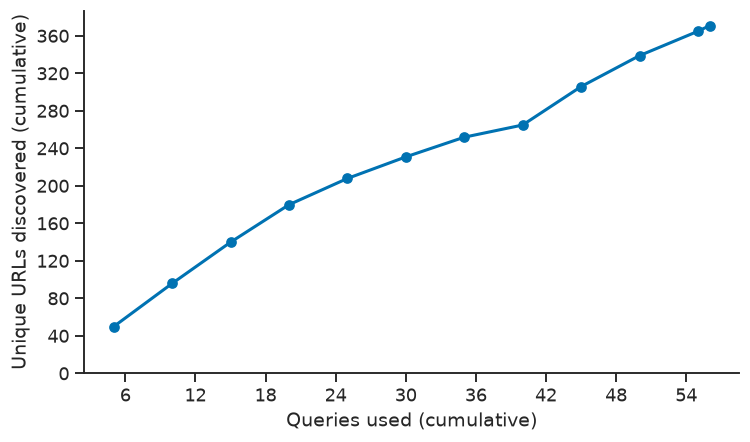

Caption: Cumulative unique URLs discovered vs. cumulative search queries spent, across 12 discovery batches (56 queries total, 371 unique URLs found).


In [2]:
fig, ax = plt.subplots()
ax.plot(df["queries_used_cumulative"], df["cumulative_unique_urls"],
        marker="o", color=PALETTE[0], linewidth=2)
ax.set_xlabel("Queries used (cumulative)")
ax.set_ylabel("Unique URLs discovered (cumulative)")
integer_axis(ax)
integer_axis(ax, axis="x")
ax.set_ylim(bottom=0)
fig.tight_layout()
savefig(fig, "discovery_cumulative_yield")
plt.show()
print(f"Caption: Cumulative unique URLs discovered vs. cumulative search queries spent, "
      f"across {len(df)} discovery batches "
      f"({int(df['queries_used_cumulative'].iloc[-1])} queries total, "
      f"{int(df['cumulative_unique_urls'].iloc[-1])} unique URLs found).")

## Marginal yield per batch

The per-batch view makes the *marginal* value of each additional batch explicit: how many
of the URLs a batch returns were actually new, versus already seen in an earlier batch
(the query templates combine a small set of keyword templates with a small set of
locations - see `search_queries.csv` - so overlap across batches is expected as the
combinatorial space of queries is exhausted).

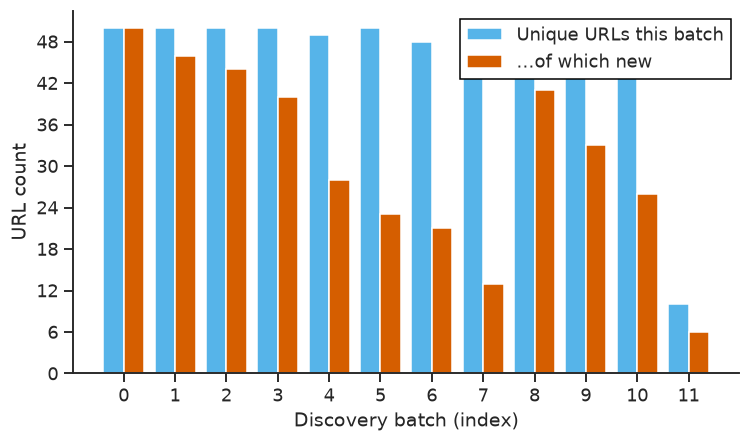

Caption: Per-batch discovery yield across 12 batches of search queries - total unique URLs returned by each batch, versus how many of those were newly discovered (not seen in an earlier batch).


In [3]:
fig, ax = plt.subplots()
x = df["batch"]
width = 0.4
ax.bar(x - width/2, df["batch_unique_urls"], width, label="Unique URLs this batch", color=PALETTE[5])
ax.bar(x + width/2, df["batch_new_urls"], width, label="...of which new", color=PALETTE[1])
ax.set_xlabel("Discovery batch (index)")
ax.set_ylabel("URL count")
integer_axis(ax)
ax.set_xticks(x)
ax.legend()
fig.tight_layout()
savefig(fig, "discovery_batch_yield")
plt.show()
print(f"Caption: Per-batch discovery yield across {len(df)} batches of "
      f"search queries - total unique URLs returned by each batch, versus how many of "
      f"those were newly discovered (not seen in an earlier batch).")

In [4]:
df["new_url_ratio"] = df["batch_new_urls"] / df["batch_unique_urls"]
summary = df[["batch", "batch_unique_urls", "batch_new_urls", "new_url_ratio"]].copy()
summary["new_url_ratio"] = (summary["new_url_ratio"] * 100).round(1)
summary.rename(columns={"new_url_ratio": "new_url_pct"})

,batch,batch_unique_urls,batch_new_urls,new_url_pct
0,0,50,50,100.0
1,1,50,46,92.0
2,2,50,44,88.0
3,3,50,40,80.0
4,4,49,28,57.1
5,5,50,23,46.0
6,6,48,21,43.8
7,7,46,13,28.3
8,8,50,41,82.0
9,9,50,33,66.0


## Discussion

The cumulative-yield curve shows discovery keeps contributing new URLs across all
measured batches rather than flattening out sharply - so, on this query set, larger
batches would *not* have been wasted API calls in the sense of returning pure duplicates.
However, the per-batch new-URL ratio is noticeably lower in the middle batches than at the
start (query/location combinations increasingly overlap in the sites they surface), then
rises again for later batches that introduce keyword templates not yet queried - i.e. the
yield curve is not monotonically decreasing, it depends on the order in which
template/location combinations happen to be enumerated.

This supports the batched design pragmatically rather than purely on diminishing returns:
running discovery in small batches, gated on the crawl queue actually being empty, means
the system never spends *any* discovery queries - let alone a large batch of them - unless
the cheaper crawl sources (starting URLs, links found while crawling) have nothing left to
offer. The batch size itself is then a tunable trade-off between search-API call volume
and how quickly a single discovery step can refill the queue.

**Limitations.** This is a single run against one query file and one search backend
(SearXNG, which itself aggregates several upstream engines - see `searxng/settings.yml`);
result sets for identical queries can change over time as the web changes and as upstream
engines are rate-limited or re-ordered, so absolute yield numbers are a snapshot, not a
long-term guarantee. `results_per_query` was left at the project's default
(`bot.config`).